In [1]:
%matplotlib inline

import os, random, time, sys, warnings
from datetime import datetime

import numpy as np
import scipy as sp
import pandas as pd
import torch
import src.utils as utils
import math
from tqdm import tqdm
from src.neural_network import ModelStateManager, ModelDataManager

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

/home/ab2792/software/miniconda3/envs/neuro_rnn/lib/python3.11/site-packages/src-0.0.0-py3.11.egg/src/plotting.py:82: DeprecationWarning: invalid escape sequence '\m'


In [2]:
# directories and files
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model'
        outdir = modeldir
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

check_only = 0
verbose = 0
save_figs = 1

# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_a_rescale.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_b_rescale_adj.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_c_mean_002.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_d_mean_001.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_e_mean_005.csv')
model_params_file = os.path.join(datadir, 'model_params_gng_5x5_mean_002_500runs.csv')
model_params = utils.load_params_csv(model_params_file)

# data parameters
dt = 100

# are we plotting results for all tasks in the list?
rows_to_plot = None
# rows_to_plot = [103]
# rows_to_plot = list(np.arange(103))
# rows_to_plot = list(np.arange(120,126))
# rows_to_plot = list(np.concatenate((np.arange(30),np.arange(45,60)))) 
if rows_to_plot is not None:
    model_params = model_params.iloc[rows_to_plot]

model_params


,task,seq_len_multi,rnn_model,hidden_size,batch_size,learning_rate,n_runs,n_epochs,mask_weights,reg_type,reg_weight,kernel_type,kernel_normalization,kernel_label
0,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.002,sa_axis,mean,Masked S-A
1,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.002,euclidean,mean,Masked Eucl.
2,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.002,None,mean,Masked Reg.
3,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.000,None,mean,Masked Unreg.
4,GoNogo-v0-Del_300_0,5,rnn-tanh,100,32,0.001,500,5000,False,l2,0.002,None,mean,Unmasked Reg.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,GoNogo-v0-Del_1100_500,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.002,euclidean,mean,Masked Eucl.
146,GoNogo-v0-Del_1100_500,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.002,None,mean,Masked Reg.
147,GoNogo-v0-Del_1100_500,5,rnn-tanh,100,32,0.001,500,5000,True,l2,0.000,None,mean,Masked Unreg.
148,GoNogo-v0-Del_1100_500,5,rnn-tanh,100,32,0.001,500,5000,False,l2,0.002,None,mean,Unmasked Reg.


# Model performance

/home/ab2792/software/miniconda3/envs/neuro_rnn/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(



Tasks:
------
GoNogo-v0-Del_300_0
GoNogo-v0-Del_300_100
GoNogo-v0-Del_300_200
GoNogo-v0-Del_300_300
GoNogo-v0-Del_300_500
GoNogo-v0-Del_500_0
GoNogo-v0-Del_500_100
GoNogo-v0-Del_500_200
GoNogo-v0-Del_500_300
GoNogo-v0-Del_500_500
GoNogo-v0-Del_700_0
GoNogo-v0-Del_700_100
GoNogo-v0-Del_700_200
GoNogo-v0-Del_700_300
GoNogo-v0-Del_700_500
GoNogo-v0-Del_900_0
GoNogo-v0-Del_900_100
GoNogo-v0-Del_900_200
GoNogo-v0-Del_900_300
GoNogo-v0-Del_900_500
GoNogo-v0-Del_1100_0
GoNogo-v0-Del_1100_100
GoNogo-v0-Del_1100_200
GoNogo-v0-Del_1100_300
GoNogo-v0-Del_1100_500

Kernel types:
-------------
Masked S-A
Masked Eucl.
Masked Reg. 
Masked Unreg. 
Unmasked Reg. 
Unmasked Unreg. 
 


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [36:57<00:00, 14.78s/it]


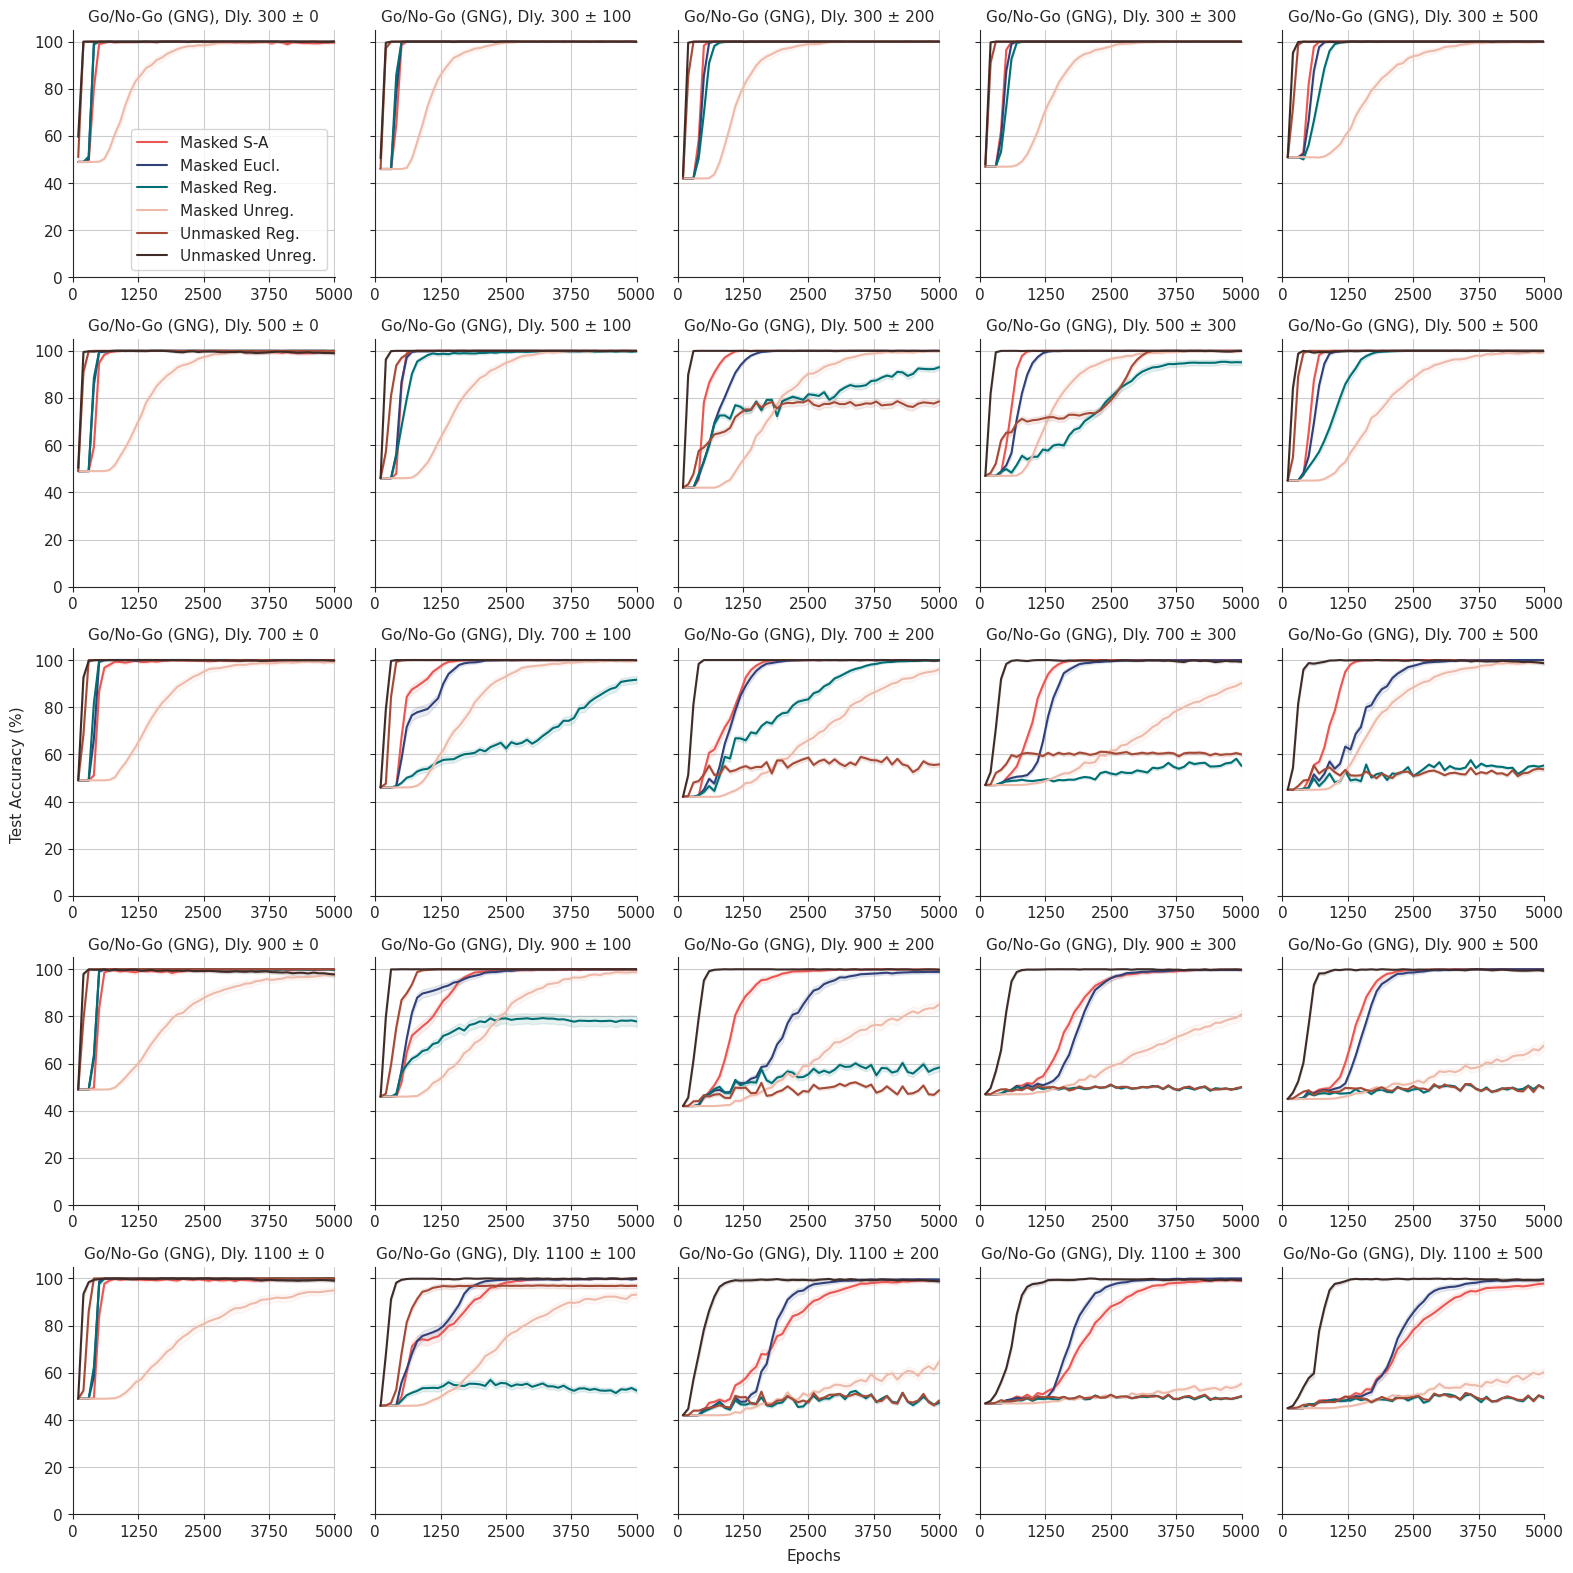

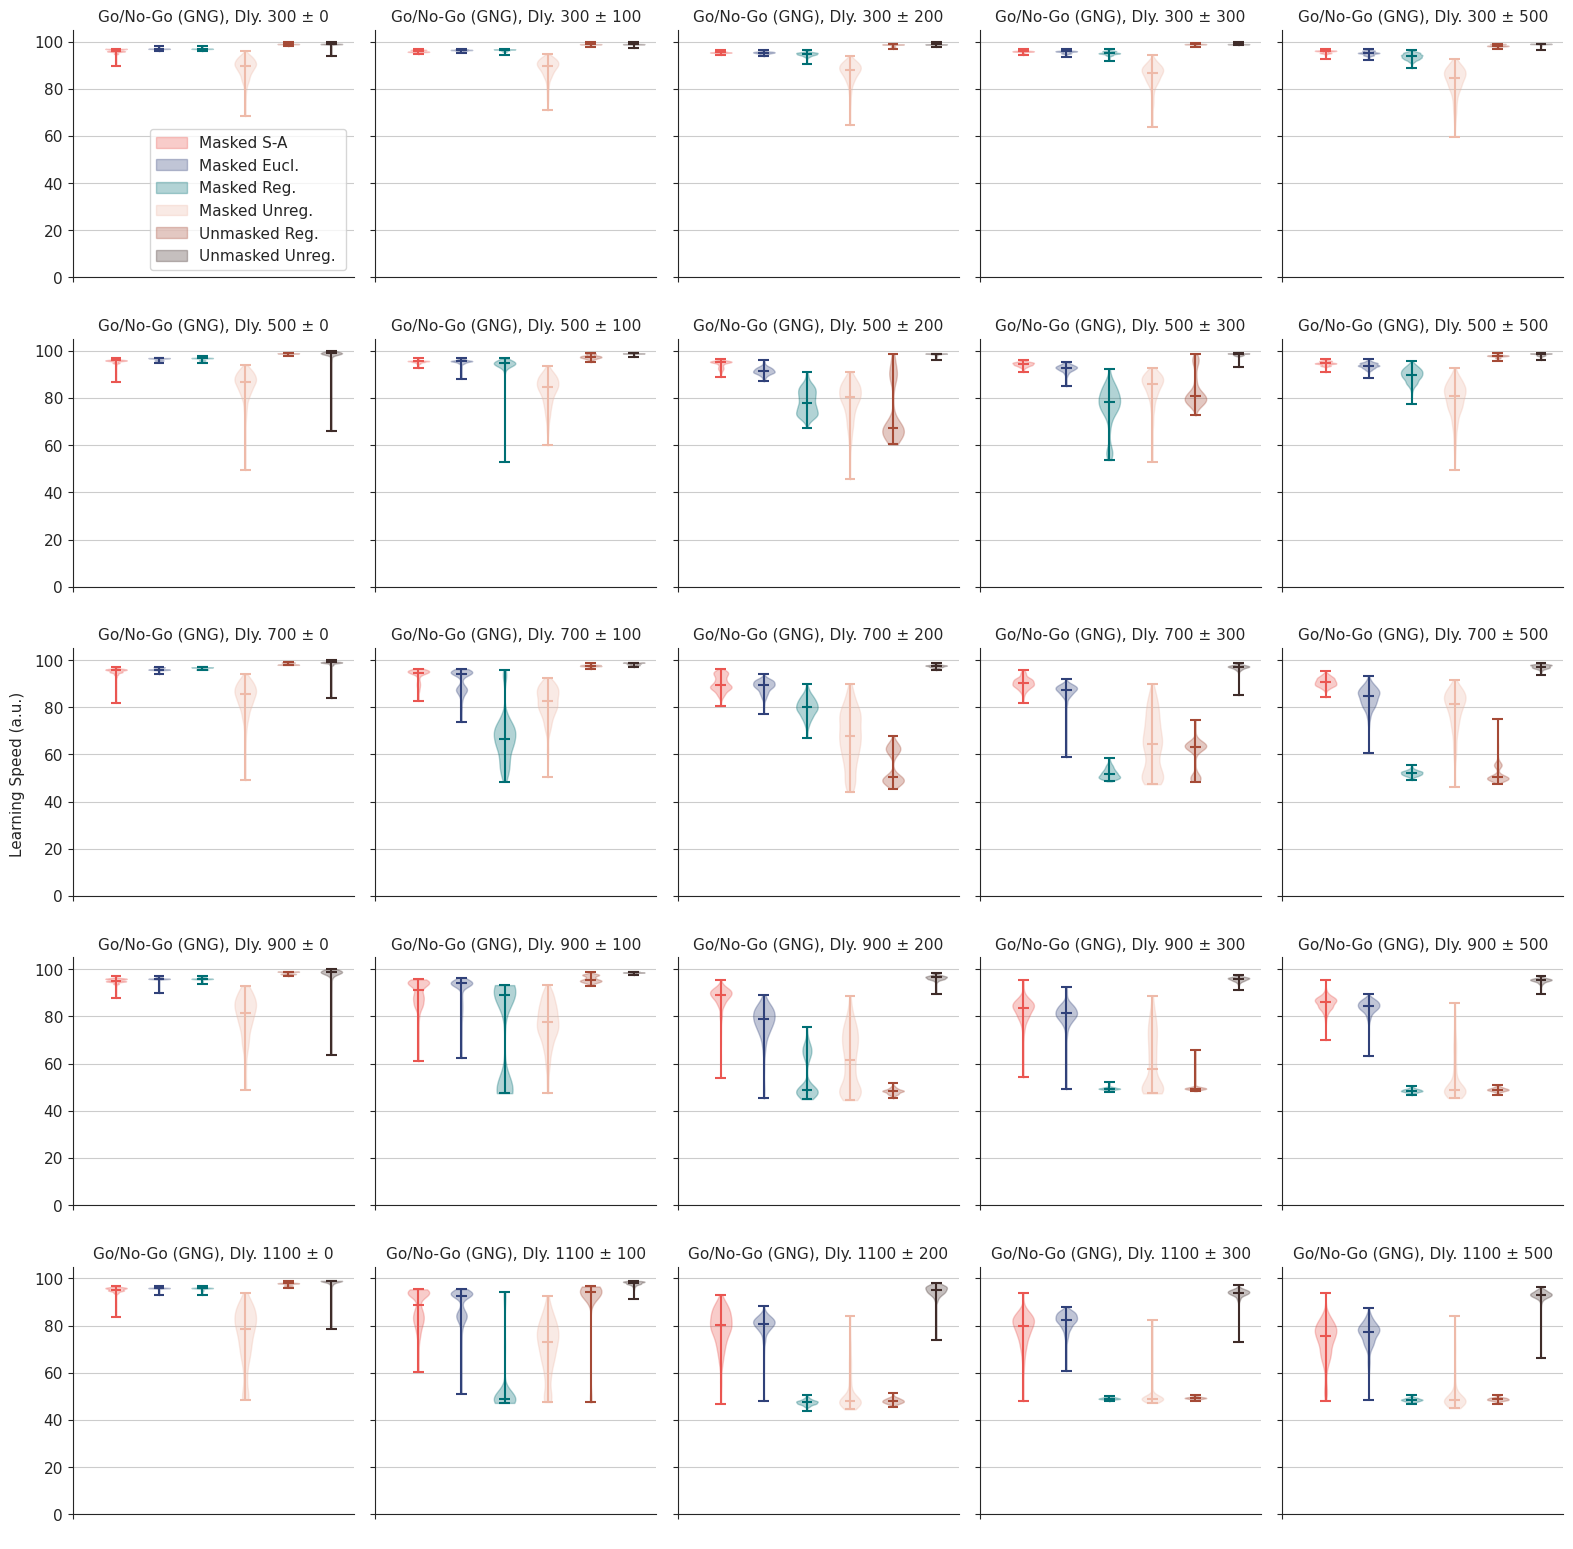

/home/ab2792/software/miniconda3/envs/neuro_rnn/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


In [3]:
# Plotting

# import colors
color_palette = utils.get_my_colors(cat_trio=False, as_list=True)

# how many tasks?
task_names_all = model_params.loc[:, 'task']
task_names = []
[task_names.append(item) for item in task_names_all if item not in task_names]
n_tasks = len(task_names)
print('\nTasks:\n------')
for i in np.arange(n_tasks):
    print(task_names[i])

# how many kernels?
kernel_labels_all = model_params.loc[:, 'kernel_label']
kernel_labels = []
[kernel_labels.append(item) for item in kernel_labels_all if item not in kernel_labels]
n_kernels = len(kernel_labels)
print('\nKernel types:\n-------------')
for i in np.arange(n_kernels):
    print(kernel_labels[i])

if not check_only:
    # initialise figure
    size_scale = 1.25
    font_size = int(9 * size_scale)
    n_fig_columns = min((5, n_tasks))
    n_fig_rows = math.ceil( n_tasks / n_fig_columns )
    fig_size_w = 2.5*n_fig_columns*size_scale
    fig_size_h = 2.5*n_fig_rows*size_scale
    f_plots, ax_plots = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                         squeeze=True, sharex=False, sharey=True)
    f_violin, ax_violin = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                         squeeze=True, sharex=False, sharey=True)
    plt.rcParams['font.size'] = font_size
    
    xlims_plots = np.zeros(n_tasks)
    violin_bodies = []

n_models = len(model_params)
found_count = 0

print(' ')

for model_idx in tqdm(np.arange(n_models)):

    if (not check_only) and verbose:
        print('\nModel index: ' + str(model_idx))
    
    # get model details
    task_with_modifier = model_params.task.iloc[model_idx] 
    kernel_type = model_params.kernel_type.iloc[model_idx] 
    mask_weights = model_params.mask_weights.iloc[model_idx] 
    reg_weight = model_params.reg_weight.iloc[model_idx] 
    n_epochs = model_params.n_epochs.iloc[model_idx] 
    n_runs = model_params.n_runs.iloc[model_idx] 
    hidden_size = model_params.hidden_size.iloc[model_idx]
    batch_size = model_params.batch_size.iloc[model_idx]
    seq_len_multi = model_params.seq_len_multi.iloc[model_idx]
    
    task_no_modifier, task_modifier = utils.get_task_modifier(task_with_modifier)
    utils.check_if_supported(task=task_no_modifier, modifier=task_modifier)
    seq_len, timing = utils.get_seq_len_and_timing(task=task_no_modifier, modifier=task_modifier, seq_len_multi=seq_len_multi)
    
    rnn_model = model_params.rnn_model.iloc[model_idx]
    learning_rate = model_params.learning_rate.iloc[model_idx]
    reg_type = model_params.reg_type.iloc[model_idx]
    n_io = utils.get_n_io(mask_weights=mask_weights, hidden_size=hidden_size)
    kernel_label = model_params.kernel_label.iloc[model_idx]
    normalization = model_params.kernel_normalization.iloc[model_idx]
    
    # prepare config
    config = {
        'dt': dt, 
        'batch_size': batch_size, 
        'rnn_model': rnn_model, 
        'n_runs': n_runs, 
        'n_epochs': n_epochs, 
        'learning_rate': learning_rate, 
        'mask_weights': mask_weights, 
        'hidden_size': hidden_size, 
        'reg_type': reg_type,
        'reg_weight': reg_weight,
        'n_io': n_io,
        'n_runs': n_runs,
        'n_epochs': n_epochs,
        'task_no_modifier': task_no_modifier,
        'task_modifier': task_modifier,
        'task_with_modifier': task_with_modifier,
        'seq_len': seq_len,
        'kernel_type': kernel_type,
        'kernel_normalization': normalization,
    }

    # get data file name
    file_str = utils.get_file_str(config)
    file_path = os.path.join(modeldir, file_str + '_outputs.h5')
    if (not check_only) and verbose:
        print(file_str)
    
    # determine task index
    task_index = task_names.index(task_with_modifier)
    if (not check_only) and verbose:
        print(task_with_modifier + '    ' + str(task_index))
    
    # determine kernel index
    kernel_index = kernel_labels.index(kernel_label)
    if (not check_only) and verbose:
        print(kernel_type + '    ' + kernel_label + '    ' + str(kernel_index))

    if check_only:
        file_exists = os.path.isfile(file_path)
        if file_exists:
            found_count += 1
        else:
            print(f'Not found ... {file_str} ({model_idx})')
        continue
    
    try:
        
        # load data
        output_manager = ModelDataManager(file_path)
        n_runs, _ = output_manager.get_info()
        test_accuracy_all = output_manager.load_key_across_runs('test_accuracy')
        
        # extract accuracy from each run
        test_accuracy = np.zeros((n_runs,test_accuracy_all[0].shape[0]-1))
        for run in np.arange(n_runs):
            test_accuracy[run,:] = test_accuracy_all[run][1:] * 100

        # # load data
        # output_manager = ModelDataManager(file_path)
        # model_data = output_manager.load_model_data()
        
        # # extract accuracy from each run
        # test_accuracy = np.zeros((n_runs,model_data[0]['test_accuracy'].shape[0]-1))
        # for run in np.arange(n_runs):
        #     test_accuracy[run,:] = model_data[run]['test_accuracy'][1:] * 100

        n_epochs_actual = test_accuracy.shape[1] * 100
        n_logged_epochs = int(n_epochs_actual / 100)
        x_step = int(n_epochs_actual / (n_logged_epochs))
        x = np.arange(x_step, n_epochs_actual + x_step, x_step)

        # compute mean and ci across runs
        accuracy_mean_runs = test_accuracy.mean(axis=0)
        accuracy_std_runs = test_accuracy.std(axis=0)
        ci = 1.96 * (accuracy_std_runs / np.sqrt(test_accuracy.shape[0]))
        ci_lower = accuracy_mean_runs - ci
        ci_upper = accuracy_mean_runs + ci
        
        # compute mean of each run across time
        accuracy_mean_epochs = test_accuracy.mean(axis=1)

        # plot mean accuracy vs. time
        f_plots.axes[task_index].plot(x, accuracy_mean_runs, color=color_palette[kernel_index], label=str(kernel_label))
        f_plots.axes[task_index].fill_between(x, ci_lower, ci_upper, color=color_palette[kernel_index], alpha=0.1)
        xlims_plots[task_index] = np.max((xlims_plots[task_index],n_epochs_actual))
        
        # plot time-averaged accuracy as violin plot
        violin_parts = f_violin.axes[task_index].violinplot(dataset=accuracy_mean_epochs, positions=[kernel_index], showmedians=True)
        for partname in ('cbars','cmins','cmaxes','cmedians'):
            vp = violin_parts[partname]
            vp.set_edgecolor(color_palette[kernel_index])
        for pc in violin_parts['bodies']:
            pc.set_facecolor(color_palette[kernel_index])
            pc.set_edgecolor(color_palette[kernel_index])
        if task_index == 0:
            violin_bodies.append(violin_parts['bodies'][0])

        # inset axis
        # if task_index == 1:
        #     x1, x2, y1, y2 = 3000, 17500, 70, 95
        #     axins = f.axes[task_index].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
        #     axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean_runs[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index])
        #     axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index], alpha=0.1)
        #     axins.patch.set_alpha(0)
        #     f.axes[task_index].indicate_inset_zoom(axins, edgecolor="black")
        
    except:
        
        print("An error occurred:", sys.exc_info()[0])
        print("Exception message:", sys.exc_info()[1])

if check_only:

    print(' ')
    print(f'Found {found_count}/{n_models} models.')
    print(' ')

else:
    
    # set title and labels for line plots
    xlim_method = 'auto' # 'auto' or x
    for task_index in np.arange(n_tasks):
        # f.axes[task_index].set_xlabel('Epochs', fontsize=font_size)
        # if task_index == 0: f.axes[task_index].set_ylabel('Test Accuracy (%)', fontsize=font_size)
        if xlim_method == 'auto':
            xmax = xlims_plots[task_index]
        else:
            xmax = xlim_method
        f_plots.axes[task_index].set_xlim([0, xmax+10])
        f_plots.axes[task_index].set_ylim([0, 105])
        f_plots.axes[task_index].set_xticks(np.arange(0,xmax+10,int(xmax/4)))
        f_plots.axes[task_index].set_yticks(np.arange(0,100+1,20))
        f_plots.axes[task_index].tick_params(bottom=True,left=True)
        if task_index == 0:
            f_plots.axes[task_index].legend(loc='lower right')
        f_plots.axes[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
        f_plots.axes[task_index].grid()
    f_plots.text(0.51, 0.0, 'Epochs', ha='center', va='center')
    f_plots.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')
    
    # set title and labels for violin plots
    for task_index in np.arange(n_tasks):
        f_violin.axes[task_index].set_ylim([0, 105])
        f_violin.axes[task_index].set_xticks(np.arange(0,n_kernels))
        f_violin.axes[task_index].set_xticks((-1,))
        f_violin.axes[task_index].set_xticklabels([' '])
        f_violin.axes[task_index].set_yticks(np.arange(0,100+1,20))
        f_violin.axes[task_index].tick_params(bottom=True,left=True)
        if task_index == 0:
            f_violin.axes[task_index].legend(violin_bodies, kernel_labels, loc='lower right')
        f_violin.axes[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
        f_violin.axes[task_index].grid()
    f_violin.text(0.0, 0.5, ' ', ha='center', va='center', rotation='vertical')
    f_violin.text(0.0, 0.5, 'Learning Speed (a.u.)', ha='center', va='center', rotation='vertical')
    
    sns.despine(fig=f_plots, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    sns.despine(fig=f_violin, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    
    f_plots.tight_layout()
    f_violin.tight_layout()
    plt.show()
    
    # save svg
    if save_figs:
        current_datetime = datetime.now()
        date_string = current_datetime.strftime("%Y%m%d%H%M%S")
        models_file = os.path.splitext(os.path.basename(model_params_file))[0]
        # file_str_plots = 'accuracy_{:}_{:}_plots.svg'.format(models_file,date_string)
        # file_str_violin = 'accuracy_{:}_{:}_violin.svg'.format(models_file,date_string)
        file_str_plots = 'accuracy_{:}_plots.svg'.format(models_file)
        file_str_violin = 'accuracy_{:}_violin.svg'.format(models_file)
        f_plots.savefig(os.path.join(outdir, file_str_plots), dpi=300, bbox_inches='tight', pad_inches=0.01)
        f_violin.savefig(os.path.join(outdir, file_str_violin), dpi=300, bbox_inches='tight', pad_inches=0.01)